In [7]:
import pandas as pd

df = pd.read_csv(r"C:\Users\Lenovo\Documents\Software comp.csv")

print(df.columns.tolist())

['Week', 'Month', 'Process_Type', 'Leads_Contacted', 'Messages_Sent', 'Followups', 'Same_Day_Followups', 'One_Day_Followups', 'Two_Day_Followups', 'ThreePlus_Day_Followups', 'Avg_Response_Lag_Hours', 'Script_Compliance_Percent', 'Message_Consistency_Percent', 'Missed_Followups', 'Time_Taken_Hours']


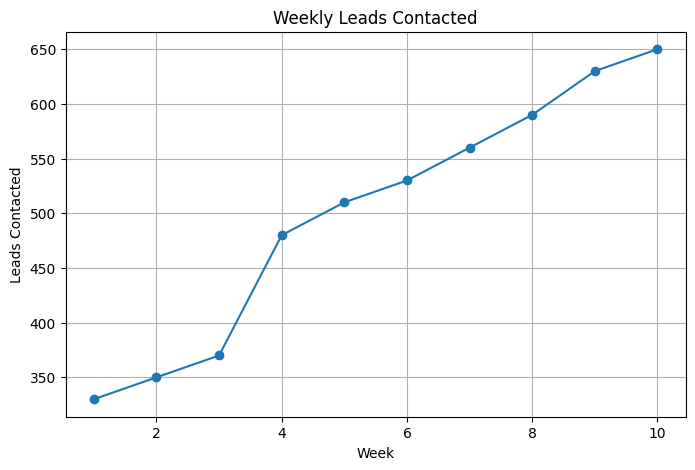

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    df["Week"],
    df["Leads_Contacted"],
    marker="o"
)

plt.title("Weekly Leads Contacted")
plt.xlabel("Week")
plt.ylabel("Leads Contacted")

plt.grid(True)
plt.show()

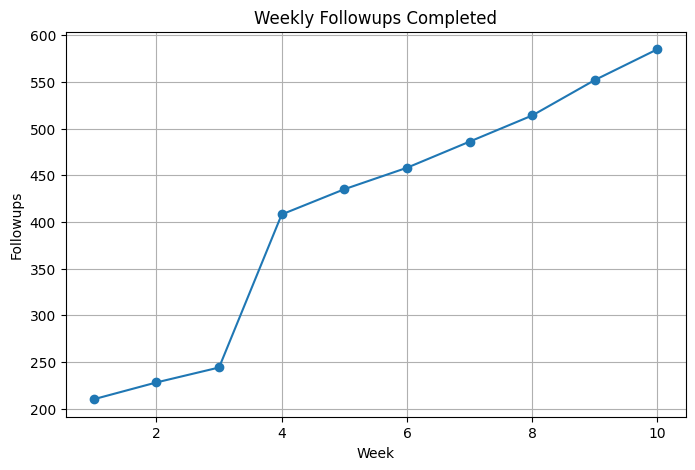

In [9]:
plt.figure(figsize=(8,5))

plt.plot(
    df["Week"],
    df["Followups"],
    marker="o"
)

plt.title("Weekly Followups Completed")
plt.xlabel("Week")
plt.ylabel("Followups")

plt.grid(True)
plt.show()

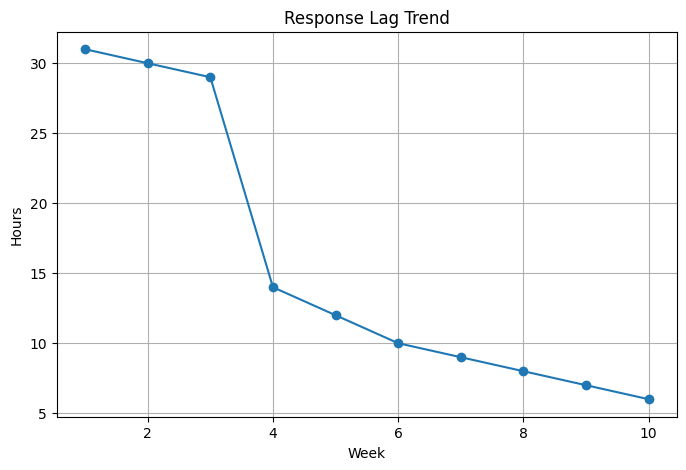

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    df["Week"],
    df["Avg_Response_Lag_Hours"],
    marker="o"
)

plt.title("Response Lag Trend")
plt.xlabel("Week")
plt.ylabel("Hours")

plt.grid(True)
plt.show()

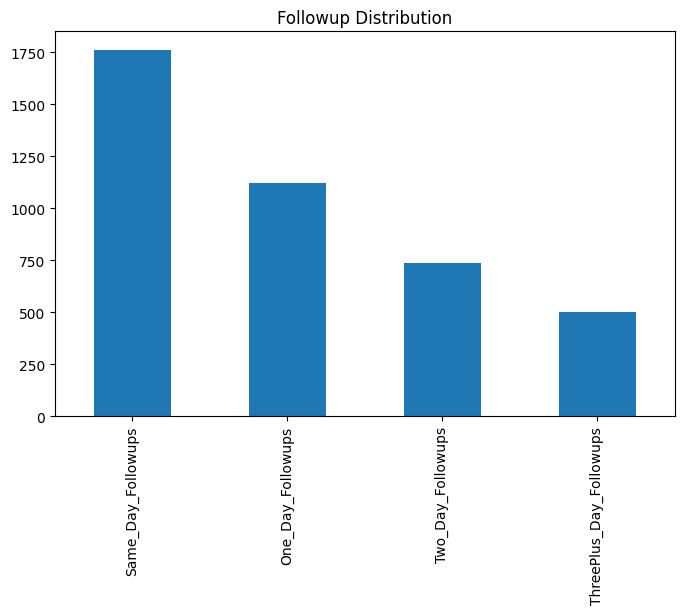

In [20]:
followups = [
    "Same_Day_Followups",
    "One_Day_Followups",
    "Two_Day_Followups",
    "ThreePlus_Day_Followups"
]
for col in followups:
    df[col]=pd.to_numeric(df[col],errors="coerce")
        
df[followups].sum().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Followup Distribution")
plt.show()

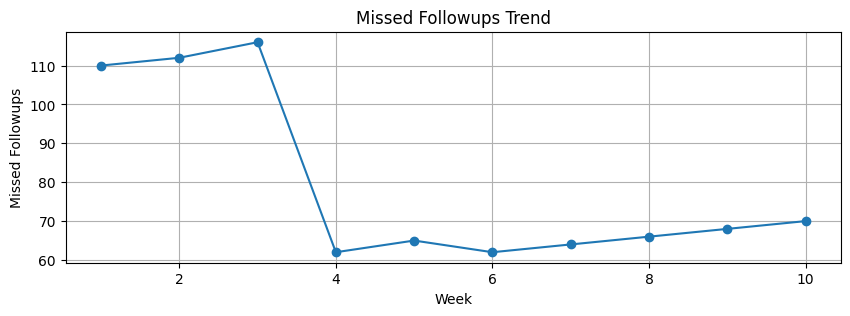

In [22]:
plt.figure(figsize=(10,3))
plt.plot(df["Week"],df["Missed_Followups"],marker="o")
plt.title("Missed Followups Trend")
plt.xlabel("Week")
plt.ylabel("Missed Followups")
plt.grid("True")
plt.show()

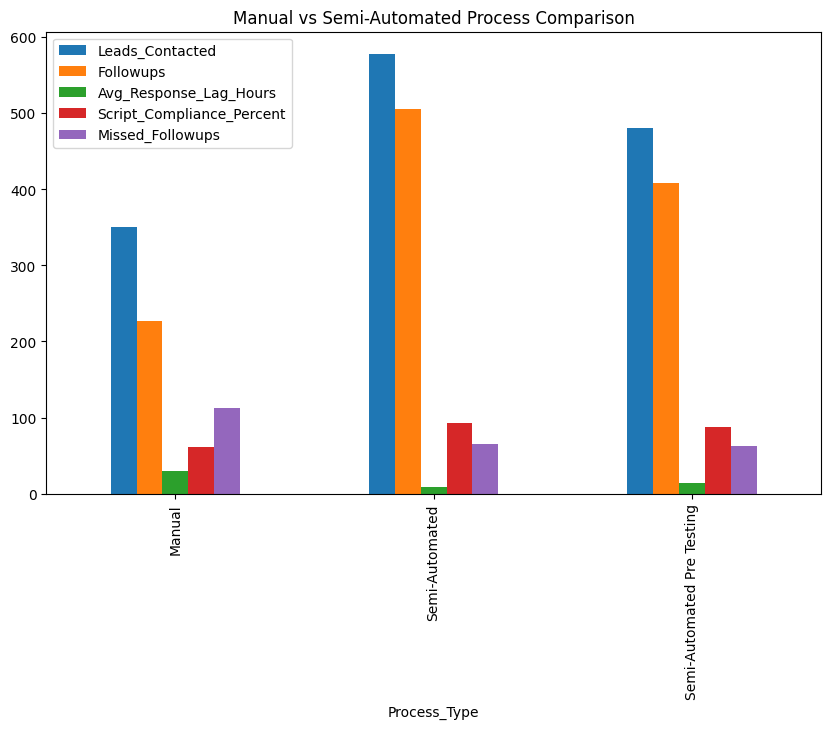

In [25]:
comparison = df.groupby(
    "Process_Type"
)[[
    "Leads_Contacted",
    "Followups",
    "Avg_Response_Lag_Hours",
    "Script_Compliance_Percent",
    "Missed_Followups"
]].mean()
comparison.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title("Manual vs Semi-Automated Process Comparison")

plt.show()

In [27]:
manual = df[
    df["Process_Type"]=="Manual"
]

auto = df[
    df["Process_Type"]=="Semi-Automated"
]

metrics = [
    "Leads_Contacted",
    "Followups",
    "Avg_Response_Lag_Hours",
    "Script_Compliance_Percent",
    "Missed_Followups"
]

for metric in metrics:

    m = manual[metric].mean()
    a = auto[metric].mean()

    change = ((a-m)/m)*100

    print(
        metric,
        round(m,2),
        round(a,2),
        round(change,2)
    )

Leads_Contacted 350.0 578.33 65.24
Followups 227.33 505.0 122.14
Avg_Response_Lag_Hours 30.0 8.67 -71.11
Script_Compliance_Percent 61.0 93.33 53.01
Missed_Followups 112.67 65.83 -41.57


In [29]:
monthly = df.groupby("Month")[
[
    "Leads_Contacted",
    "Followups",
    "Same_Day_Followups",
    "Avg_Response_Lag_Hours"
]
].mean()

print(monthly)

       Leads_Contacted  Followups  Same_Day_Followups  Avg_Response_Lag_Hours
Month                                                                        
April            408.0      305.0               102.2                    23.2
May              592.0      519.0               250.2                     8.0
